   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 34.8 MB/s eta 0:00:00


In [1]:
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
import pandas as pd
import tempfile

ModuleNotFoundError: No module named 'bs4'

# Gravity Place 投稿データスクレイピング概要

Seleniumを使用して「https://www.gravity.place/star/6?tag=new」

ページの投稿データを自動で取得します。ヘッドレスモードのChromeブラウザを起動し、「もっとみる」ボタンを複数回クリックして投稿を次々に読み込みます。ポップアップが表示された場合は自動で閉じる処理も行います。

ページのHTMLを取得後、BeautifulSoupで解析し、各投稿のユーザー名、投稿日時、内容、画像URL、投稿URLを抽出します。抽出したデータはPandasのDataFrameにまとめられ、UTF-8 BOM付きのCSVファイルとして保存されます。

これにより、ポップアップ対応と動的読み込みを含むサイトから効率的に投稿情報を収集できる仕組みとなっています。

In [91]:
%%time

options = Options()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument(f'--user-data-dir={tempfile.mkdtemp()}')

driver = webdriver.Chrome(options=options)
driver.get("https://www.gravity.place/star/6?tag=new")
wait = WebDriverWait(driver, 10)

for i in range(500):
    try:
        try:
            close_btn = WebDriverWait(driver, 3).until(
                EC.element_to_be_clickable((By.CLASS_NAME, 'close'))
            )
            driver.execute_script("arguments[0].click();", close_btn)
            print("✅ ポップアップを閉じました")
            time.sleep(1)
        except:
            print("ℹ️ 閉じるべきポップアップはありません")

        WebDriverWait(driver, 15).until(
            EC.presence_of_all_elements_located((By.CLASS_NAME, 'more-comment'))
        )
        more_buttons = driver.find_elements(By.CLASS_NAME, 'more-comment')

        print(f"🔍 「もっとみる」ボタンが{len(more_buttons)}個見つかりました")

        if len(more_buttons) < 2:
            print("⚠️ 2番目のボタンが見つからなかったため、ループを抜けます")
            break

        more_btn = more_buttons[1]
        print(f"✅ {i+1} 回目の「もっとみる」ボタンをクリック")

        visible = driver.execute_script("return arguments[0].offsetParent !== null;", more_btn)
        print("ボタンは表示されていますか：", visible)
        driver.execute_script("arguments[0].click();", more_btn)
        time.sleep(3)
    except Exception as e:
        print("❌ エラーまたはボタンが存在しません:", e)
        break

html = driver.page_source
driver.quit()

soup = BeautifulSoup(html, 'html.parser')
results = []

for post in soup.find_all('a', href=True):
    try:
        if not post['href'].startswith('/detail/'):
            continue
        wrapper = post.find('div', class_='feed-card-list-item')
        if wrapper is None:
            continue

        username = wrapper.find('p', class_='user-name').text.strip()
        post_time = wrapper.find('time')['datetime'].strip()
        content_raw = wrapper.find('article', class_='desc')
        content = content_raw.get_text(separator='\n', strip=True) if content_raw else ''

        image_tags = wrapper.select('section.multiple-images img')
        image_urls = [img['src'] for img in image_tags if img.get('src')]

        post_url = "https://www.gravity.place" + post['href']

        results.append({
            'username': username,
            'post_time': post_time,
            'content': content,
            'image_url': ', '.join(image_urls),
            'post_url': post_url
        })

    except Exception as e:
        print("⚠️ 投稿の取得エラー：", e)

df = pd.DataFrame(results)
df.to_csv('gravity_posts.csv', index=False, encoding='utf-8-sig')
print(f"✅ 合計で{len(df)}件の投稿を保存しました")

ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 1 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
✅ ポップアップを閉じました
🔍 「もっとみる」ボタンが2個見つかりました
✅ 2 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 3 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 4 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 5 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 6 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 7 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 8 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 9 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 10 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 11 回目の「もっとみる」ボタンをクリック
ボタンは表示されていますか： True
ℹ️ 閉じるべきポップアップはありません
🔍 「もっとみる」ボタンが2個見つかりました
✅ 1

In [92]:
df

,username,post_time,content,image_url,post_url
0,Δ(デルタ),2022/09/09,今日仕事終われば嫁とスプラ3！\n今日仕事終われば嫁とスプラ3！\n今日仕事終われば嫁とスプ...,,https://www.gravity.place/detail/4_8372807
1,夢,2025/04/03,友達がゲーム会社で働いてて最高な瞬間\n〜ニンテンドーダイレクト視聴中〜\n俺「あれこれもし...,,https://www.gravity.place/detail/1_28203735
2,うさぎ色,2022/05/30,どうぶつの森好きのゲーム部屋🤭\n#あつ森\n#あつまれどうぶつの森,https://cdn.gravity.place/feed/img/2022-05-30/...,https://www.gravity.place/detail/7_7148037
3,たぬ○(、._. )、,2023/11/12,可愛いローバちゃん見て？((˙꒳˙ก̀))\nスパレジェ昨日当たって\nほんとはずっとキル数...,https://cdn.gravity.place/feed/img/2023-11-12/...,https://www.gravity.place/detail/6_14785991
4,ノウン,2022/10/26,そーゆーのひとつでモチベ上がる,https://cdn.gravity.place/feed/img/2022-10-26/...,https://www.gravity.place/detail/4_8979168
...,...,...,...,...,...
3423,riyu,2025/06/02,ニーアオートマタの話。\n妹が昔やってたの隣で見てたんだけど隠し最強ボス？のエミールを難なく...,,https://www.gravity.place/detail/8_30046074
3424,あいな🌷,2025/06/02,PS5フレンドになってくれる方いませんか〜\n08/🚺/Switchもあります.ᐟ‪‪‬.ᐟ...,,https://www.gravity.place/detail/3_30028843
3425,なーたん,2025/06/02,バイオハザード5\nマイクラ等\n友達募集中です。,,https://www.gravity.place/detail/3_30028764
3426,ちろく,2025/06/02,#ひとりごとのようなもの\n#SKY星を紡ぐ子どもたち\nフレ様に教えてもらってやってみた結...,https://cdn.gravity.place/feed/img/2025-06-02/...,https://www.gravity.place/detail/2_30232630


In [82]:
import pandas as pd
from datetime import datetime, timedelta

In [93]:
df['post_time'] = pd.to_datetime(df['post_time'], format='%Y/%m/%d')

today = datetime.today()

one_month_ago = today - timedelta(days=30)

df_filtered = df[df['post_time'] >= one_month_ago].reset_index(drop=True)

In [94]:
df_filtered

,username,post_time,content,image_url,post_url
0,マサ坊,2025-06-30,普段シミュレーションゲームしないのに\nこれはめっちゃハマった,https://cdn.gravity.place/feed/img/2025-06-30/...,https://www.gravity.place/detail/6_30979223
1,ハヤさん,2025-06-30,遊んでていちばん思うことは、なぜ、スージィを抱きしめるコマンドが無いんだ…！\n#Delta...,,https://www.gravity.place/detail/8_30951028
2,桜夜,2025-06-30,龍が如く,,https://www.gravity.place/detail/7_31062423
3,ユウ,2025-06-30,この2体同時は熱い[大笑い]\n#Gジェネエターナル,https://cdn.gravity.place/feed/img/2025-06-30/...,https://www.gravity.place/detail/1_30990524
4,ナオト＝ラム,2025-06-30,ギラティナの存在、完全に忘れてて今入手した。\nポケモン好きだけど、アルセウス持ってない。\...,https://cdn.gravity.place/feed/img/2025-06-30/...,https://www.gravity.place/detail/7_31062316
...,...,...,...,...,...
3413,riyu,2025-06-02,ニーアオートマタの話。\n妹が昔やってたの隣で見てたんだけど隠し最強ボス？のエミールを難なく...,,https://www.gravity.place/detail/8_30046074
3414,あいな🌷,2025-06-02,PS5フレンドになってくれる方いませんか〜\n08/🚺/Switchもあります.ᐟ‪‪‬.ᐟ...,,https://www.gravity.place/detail/3_30028843
3415,なーたん,2025-06-02,バイオハザード5\nマイクラ等\n友達募集中です。,,https://www.gravity.place/detail/3_30028764
3416,ちろく,2025-06-02,#ひとりごとのようなもの\n#SKY星を紡ぐ子どもたち\nフレ様に教えてもらってやってみた結...,https://cdn.gravity.place/feed/img/2025-06-02/...,https://www.gravity.place/detail/2_30232630


SNS投稿データ（`df_filtered`）の「内容」からゲーム名の言及を抽出し、日付ごとに各ゲームの言及回数を集計して、ピボットテーブル形式で整理しています。

- `game_aliases_raw` にはゲームの正式名称とその別名（エイリアス）が辞書形式でまとめられています。
- すべての別名を小文字化して `synonym_map` に登録し、検索用の正規表現 `game_regex` を作成しています。
- 関数 `extract_standard_games` は、テキスト中にあるゲーム名の別名を検出し、正式名称に統一してリストで返します。
- `df_filtered` の「content」列に対してこの関数を適用し、新たに「mentioned game」列を作成します。
- 各投稿の投稿日（`post_time`）とゲーム名の組み合わせごとに出現回数をカウントし、`df_game_by_date` にまとめます。
- 最後にピボットテーブル `pivot_df` を作成し、行が日付、列がゲーム名、値が言及回数となる表に変換します。
- 欠損値は0で埋め、日付は降順でソートしています。

これにより、日ごとにどのゲームがどのくらい言及されているかを分析しやすい形式で確認できます。


In [95]:
import re
import pandas as pd
from collections import Counter

game_aliases_raw = {
    'Apex Legends': ['apex', 'エペ', 'Apex'],
    'ポケモンGO': ['ポケモンGO', 'pokemon go'],
    'スプラトゥーン': ['スプラ', 'スプラ3', 'スプラトゥーン'],
    'あつまれ どうぶつの森': ['あつ森'],
    'Call of Duty Mobile': ['CODモバイル', 'Call of Duty'],
    '雀魂': ['雀魂', 'じゃんたま'],
    'ゼルダの伝説': ['ゼルダ', 'ブレワイ', 'Tears of the Kingdom'],
    'マインクラフト': ['マイクラ', 'Minecraft'],
    'スマブラ': ['スマブラ', '大乱闘スマッシュブラザーズ'],
    'モンハン': ['モンハン', 'モンスターハンター', 'MH', 'MHXX', 'MHWI', 'モンハンライズ', 'モンハンワールド'],
    'コンパス': ['コンパス', '#コンパス', 'コンパス戦闘摂理解析システム', '#コンパス【戦闘摂理解析システム】'],
    '原神': ['原神', 'げんしん', 'Genshin', 'Genshin Impact', '原神インパクト'],
    'VALORANT': ['VALORANT', 'ヴァロラント', 'ヴァロ', 'バロラント', 'バロ'],
    'Overwatch': ['Overwatch', 'オーバーウォッチ', 'オバウォ', 'オバッチ', 'OW'],
    'Dead by Daylight': ['Dead by Daylight', 'DBD', 'デッドバイデイライト', 'デドバ', 'デッバイ'],
    'Pokémon Trading Card Game Pocket': ['ポケポケ'],
    'Sky': [
    'Sky',
    'Sky Children of the Light',
    'Sky: Children of the Light',
    'スカイ',
    'スカイ チルドレン オブ ザ ライト',
    'スカイ 子供たちの光',
    'Sky 子供たちの光',
    'スカイライト',
    'スカイコドリ',
    '空の子供たち',
    ],
    'FF14': [
    'FF14',
    'エフエフ14',
    'ファイナルファンタジー14',
    'ファイナルファンタジーXIV',
    'FFXIV',
    'エフエフエックスアイブイ',
    'FFXIV: 新生エオルゼア',
    '新生エオルゼア',
    'FF14オンライン',
    ],
    'Roblox': [
    'Roblox',
    'ロブロックス',
    'ロブロックスゲーム',
    'ロブロックスプラットフォーム',
    'ロブロ'
    ],
    'LOL': [
    'LOL',
    'リーグ・オブ・レジェンド',
    'リーグオブレジェンド',
    'リーグ・オブ・レジェンズ',
    'リーグオブレジェンズ',
    'リーグ',
    'LoL',
    'ロル',
    ],
    'ウマ娘': [
    'ウマ娘',
    'ウマ娘 プリティーダービー',
    'ウマ娘プリティーダービー',
    'ウマ娘 プリティダービー',
    'ウマ娘プリティダービー',
    'ウマムスメ',
    'Uma Musume',
    ],
    'ペルソナ': [
    'ペルソナ',
    'Persona',
    'ペルソナシリーズ',
    'ペルソナ5',
    'ペルソナ4',
    'P5',
    'P4',
    ],
    '第五人格': [
    '第五人格',
    '第5人格',
    'Identity V',
    'アイデンティティV',
    'アイデンティティファイブ',
    '第五人格（Identity V）',
    '第五'
    ],
    'Honkai: Star Rail': [
    '崩壊：星穹鉄道',
    'Honkai: Star Rail',
    'ホンカイ：スター レイル',
    ],
    'フォートナイト': [
    'フォートナイト',
    'Fortnite',
    'フォトナ',
    'フォトナイト',
]
}

synonym_map = {}
for game, aliases in game_aliases_raw.items():
    for alias in aliases:
        synonym_map[alias.lower()] = game

game_patterns = [re.escape(k) for k in synonym_map.keys()]
game_regex = re.compile('|'.join(game_patterns), flags=re.IGNORECASE)

def extract_standard_games(text):
    if not isinstance(text, str):
        return []
    matches = game_regex.findall(text)
    standardized = []
    for m in matches:
        key = m.lower()
        standardized.append(synonym_map.get(key, m))
    return list(set(standardized))

df_filtered['mentioned game'] = df_filtered['content'].apply(extract_standard_games)

rows = []
for _, row in df_filtered.iterrows():
    date = row['post_time']
    for game in row['mentioned game']:
        rows.append((date, game))

df_game_by_date = (
    pd.DataFrame(rows, columns=['post_time', 'game'])
    .value_counts()
    .reset_index(name='mentioned time')
    .sort_values(by=['post_time', 'mentioned time'], ascending=[False, False])
)

df_game_by_date.reset_index(drop=True, inplace=True)

df_game_by_date = (
    pd.DataFrame(rows, columns=['post_time', 'game'])
    .value_counts()
    .reset_index(name='mentioned time')
)

pivot_df = df_game_by_date.pivot(index='post_time', columns='game', values='mentioned time')

pivot_df = pivot_df.fillna(0).astype(int)

pivot_df = pivot_df.sort_index(ascending=False)

In [96]:
pivot_df

game,Apex Legends,Call of Duty Mobile,Dead by Daylight,FF14,LOL,Overwatch,Pokémon Trading Card Game Pocket,Roblox,Sky,VALORANT,...,スマブラ,ゼルダの伝説,フォートナイト,ペルソナ,ポケモンGO,マインクラフト,モンハン,原神,第五人格,雀魂
post_time,,,,,,,,,,,,,,,,,,,,,
2025-06-30,0,0,0,0,0,0,0,0,0,0,...,1,0,0,2,1,1,1,0,0,1
2025-06-29,5,0,2,2,1,2,2,1,3,4,...,0,2,2,4,0,3,7,2,3,1
2025-06-28,3,0,2,0,0,0,0,1,3,2,...,1,2,0,6,0,1,4,4,0,0
2025-06-27,6,0,2,1,0,3,3,0,1,2,...,0,0,2,10,0,1,3,2,0,0
2025-06-26,0,1,0,0,0,1,7,0,5,1,...,0,1,0,7,0,2,5,3,2,0
2025-06-25,2,0,0,1,0,1,2,0,2,0,...,2,0,1,5,1,1,3,4,1,0
2025-06-24,3,0,0,2,4,1,0,0,5,2,...,0,1,0,0,1,0,4,2,1,0
2025-06-23,3,0,0,0,3,1,0,0,2,3,...,0,1,1,4,0,3,2,4,2,1
2025-06-22,6,0,2,2,4,4,2,0,6,3,...,1,3,1,0,0,1,6,4,1,0


In [72]:
!pip install japanize-matplotlib

先ほど作成したゲーム言及回数のピボットテーブル（`pivot_df`）から特定のゲームの言及回数推移を折れ線グラフで可視化する処理です。

- `games_to_plot` で表示したいゲーム名をリストで指定しています。
- `available_games` では、実際に `pivot_df` の列に存在するゲームだけを抽出しており、存在しないゲームがあってもエラーにならないようにしています。
- `plt.figure(figsize=(12, 6))` でグラフのサイズを指定。
- それぞれのゲームについて、日付（`pivot_df.index`）を横軸、言及回数を縦軸に折れ線グラフを作成し、マーカー付きで描画します。
- グラフタイトル、軸ラベル、X軸のラベルを45度回転して見やすくし、凡例を表示。
- `plt.tight_layout()` でレイアウトの余白を調整し、`plt.show()` でグラフを表示します。

指定した複数のゲームの言及数の推移を日付ごとに比較できます。


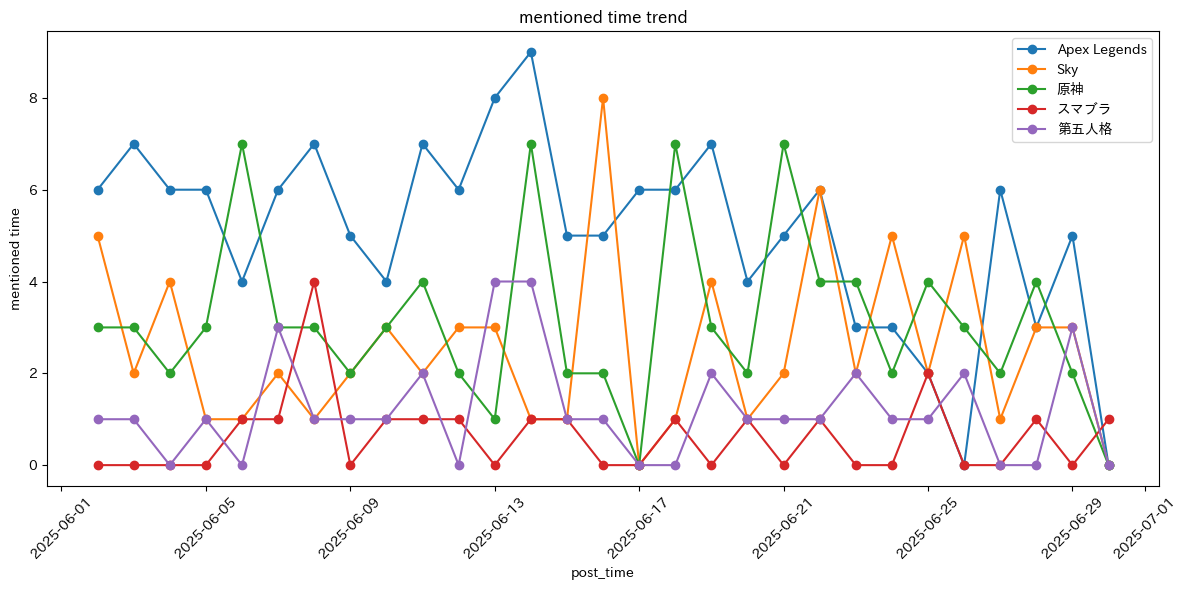

In [99]:
import matplotlib.pyplot as plt
import japanize_matplotlib

games_to_plot = ['Apex Legends', 'Sky', '原神', 'スマブラ', '第五人格']

available_games = [game for game in games_to_plot if game in pivot_df.columns]

plt.figure(figsize=(12, 6))
for game in available_games:
    plt.plot(pivot_df.index, pivot_df[game], marker='o', label=game)

plt.title('mentioned time trend')
plt.xlabel('post_time')
plt.ylabel('mentioned time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


特定の日付（この場合は `'2025-06-30'`）におけるゲームの言及回数を棒グラフで可視化する処理です。

- `date_to_plot` に表示したい日付を指定しています。

これにより、指定した日の中でどのゲームがどれだけ言及されたかを視覚的に把握できます。


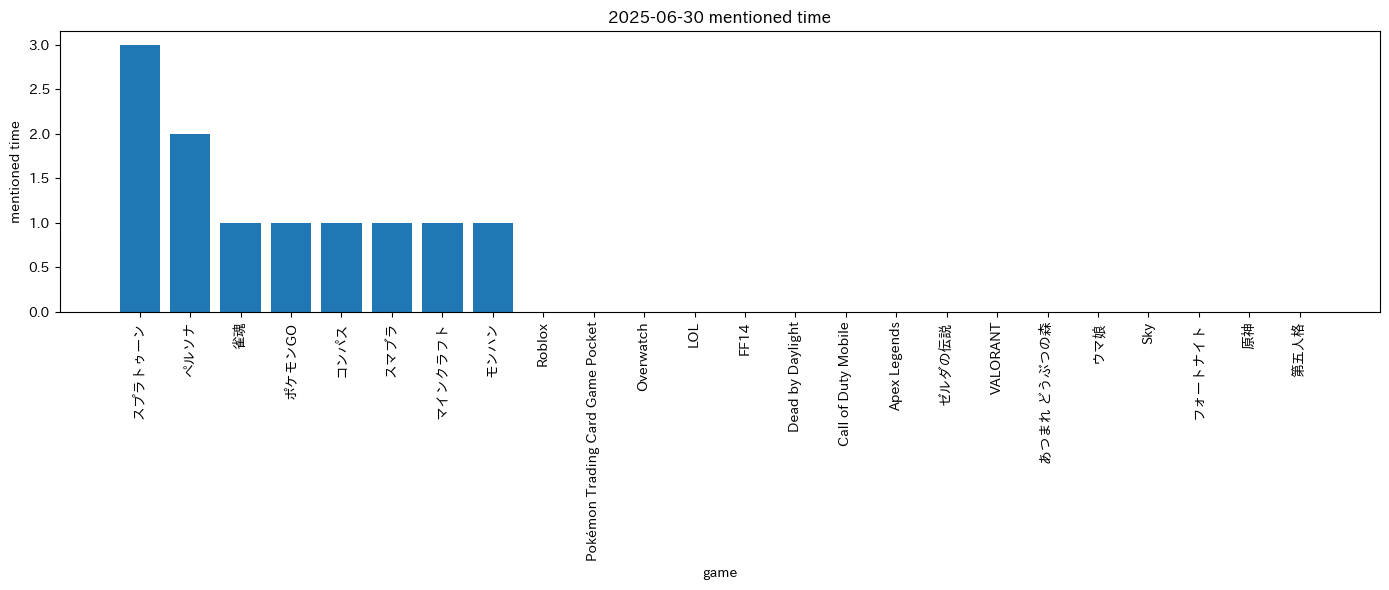

In [100]:
date_to_plot = '2025-06-30'
data = pivot_df.loc[date_to_plot]

plt.figure(figsize=(14,6))
data_sorted = data.sort_values(ascending=False)

plt.bar(data_sorted.index, data_sorted.values)
plt.title(f'{date_to_plot} mentioned time')
plt.xlabel('game')
plt.ylabel('mentioned time')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

全期間のゲーム別の言及回数の累計を計算し、その中で言及回数が多い上位10ゲームを横棒グラフで表示する処理です。

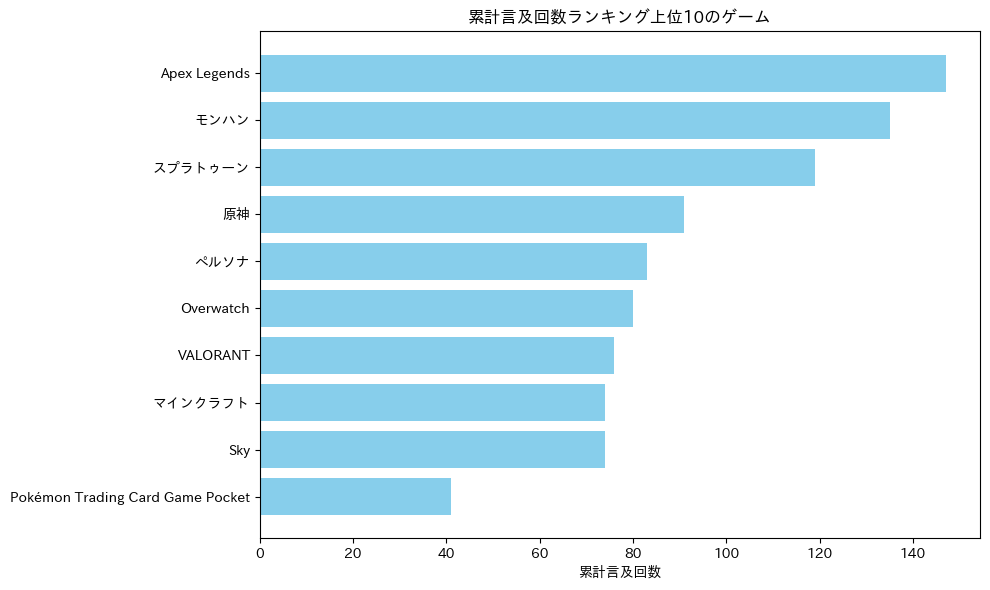

In [101]:
total_mentions = pivot_df.sum(axis=0).sort_values(ascending=True)
top_n = 10
top_games = total_mentions[-top_n:]

plt.figure(figsize=(10,6))
plt.barh(top_games.index, top_games.values, color='skyblue')
plt.title(f'累計言及回数ランキング上位{top_n}のゲーム')
plt.xlabel('累計言及回数')
plt.tight_layout()
plt.show()


ゲームごとの言及回数データに基づいて相関行列を計算し、ヒートマップとして可視化する処理です。

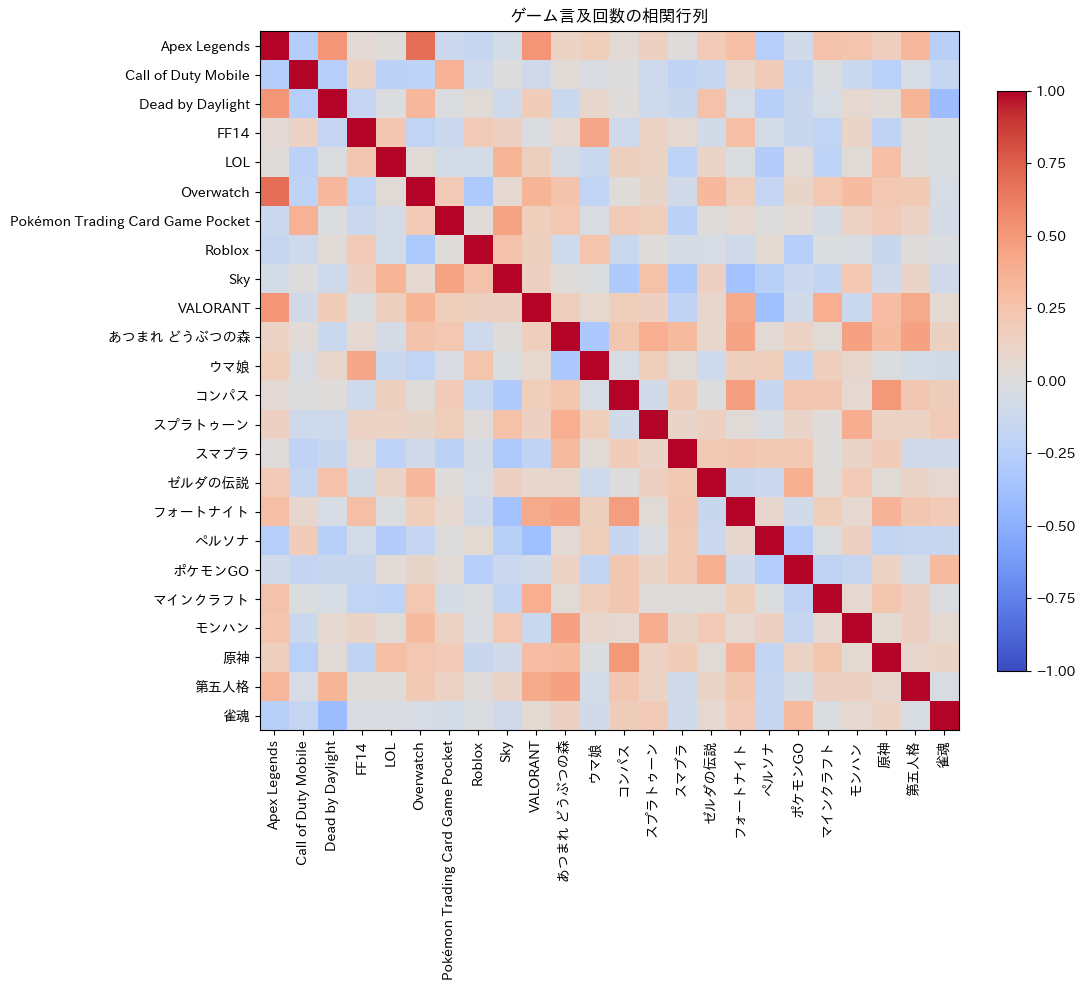

In [102]:
import numpy as np

corr_matrix = pivot_df.corr()

plt.figure(figsize=(12,10))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.03, pad=0.04)
plt.title('ゲーム言及回数の相関行列')

plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns)
plt.tight_layout()
plt.show()
